# Ekstraklasa 2025-26 - Three Clubs Analysis

Comparative analysis of three Polish football clubs across the 2025-26 Ekstraklasa season:

- **Lech Poznań** - the champion
- **Jagiellonia Białystok** - Europa League via 3rd place
- **Legia Warszawa** - mid-table, no European football

Data sources: football-data.co.uk for match results, FBref for team and player stats
(scraped via Chrome DevTools Protocol to bypass Cloudflare).



## 1. League snapshot

Final standings give the context for everything that follows.

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
#Helpers
def load_match_log(team_key: str) -> pd.DataFrame:
    df = pd.read_csv(f"{DATA}/{team_key}_match_log.csv")
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).reset_index(drop=True)
    df = df[df["Comp"] == "Ekstraklasa"].sort_values("Date").reset_index(drop=True)
    df["GF"] = pd.to_numeric(df["GF"], errors="coerce").astype("Int64")
    df["GA"] = pd.to_numeric(df["GA"], errors="coerce").astype("Int64")
    df["Poss"] = pd.to_numeric(df["Poss"], errors="coerce")
    df["Pts"] = df["Result"].map({"W": 3, "D": 1, "L": 0})
    df["cum_pts"] = df["Pts"].cumsum()
    df["matchweek"] = df.index + 1
    return df


NUMERIC_COLS = [
    "MP", "Starts", "Min", "90s",
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt", "CrdY", "CrdR",
    "Gls_per90", "Ast_per90", "G+A_per90", "G-PK_per90", "G+A-PK_per90",
]


def flatten_player_cols(df: pd.DataFrame) -> pd.DataFrame:
    new_cols = []
    for c in df.columns:
        top, sub = c
        if str(top).startswith("Unnamed"):
            new_cols.append(sub)
        elif "Per 90" in str(top):
            new_cols.append(f"{sub}_per90")
        else:
            new_cols.append(sub)
    df = df.copy()
    df.columns = new_cols
    df = df[~df["Player"].astype(str).str.contains("Total|Player", na=False, regex=True)]
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["Gls"]).reset_index(drop=True)
    return df


def load_player_standard(team_key: str) -> pd.DataFrame:
    df = pd.read_csv(f"{DATA}/{team_key}_player_standard.csv", header=[0, 1])
    return flatten_player_cols(df)


def top_contributors(team_key: str, n: int = 5) -> pd.DataFrame:
    df = load_player_standard(team_key)
    cols = ["Player", "Pos", "Age", "MP", "Min", "Gls", "Ast", "G+A"]
    return df.sort_values("G+A", ascending=False).head(n)[cols].reset_index(drop=True)


def load_gk(team_key: str) -> pd.DataFrame:
    df = pd.read_csv(f"{DATA}/{team_key}_player_goalkeeping.csv", header=[0, 1])
    new_cols = []
    for top, sub in df.columns:
        if str(top).startswith("Unnamed"):
            new_cols.append(sub)
        elif str(top) == "Penalty Kicks":
            new_cols.append(f"PK_{sub}")
        else:
            new_cols.append(sub)
    df = df.copy()
    df.columns = new_cols
    df = df[~df["Player"].astype(str).str.contains("Total|Player", na=False, regex=True)]
    for col in ["MP", "Starts", "Min", "90s", "GA", "GA90", "SoTA", "Saves", "Save%",
                "W", "D", "L", "CS", "CS%"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["Min"]).reset_index(drop=True)
    return df


def split_season(df: pd.DataFrame) -> pd.DataFrame:
    half = ["Autumn" if mw <= 17 else "Spring" for mw in df["matchweek"]]
    df = df.assign(half=half)
    agg = (df.groupby("half")
             .agg(MP=("Pts", "size"),
                  W=("Result", lambda s: (s == "W").sum()),
                  D=("Result", lambda s: (s == "D").sum()),
                  L=("Result", lambda s: (s == "L").sum()),
                  GF=("GF", "sum"),
                  GA=("GA", "sum"),
                  Pts=("Pts", "sum"))
             .reset_index())
    agg["PPG"] = (agg["Pts"] / agg["MP"]).round(2)
    return agg


def home_away_split(df: pd.DataFrame) -> pd.DataFrame:
    agg = (df.groupby("Venue")
             .agg(MP=("Pts", "size"),
                  W=("Result", lambda s: (s == "W").sum()),
                  D=("Result", lambda s: (s == "D").sum()),
                  L=("Result", lambda s: (s == "L").sum()),
                  GF=("GF", "sum"),
                  GA=("GA", "sum"),
                  Pts=("Pts", "sum"))
             .reset_index())
    agg["PPG"] = (agg["Pts"] / agg["MP"]).round(2)
    return agg


buckets_order = [
    "Big win (+3 or more)",
    "Win (+1 or +2)",
    "Draw",
    "Loss (-1 or -2)",
    "Heavy loss (-3 or worse)",
]


def bucket_margin(gd: int) -> str:
    if gd >= 3:  return "Big win (+3 or more)"
    if gd >= 1:  return "Win (+1 or +2)"
    if gd == 0:  return "Draw"
    if gd >= -2: return "Loss (-1 or -2)"
    return "Heavy loss (-3 or worse)"


logs = {team: load_match_log(key) for team, key in TEAM_FILE.items()}
print("Loaded match logs:")
for team, df in logs.items():
    print(f"  {team:<15} {len(df)} matches")

Loaded match logs:
  Lech Poznań     34 matches
  Jagiellonia     34 matches
  Legia Warsaw    34 matches


In [40]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

DATA = '/content/drive/MyDrive/ekstraklasa-2025-26'

standings = pd.read_csv(f'{DATA}/league_standings.csv')
print(f'shape: {standings.shape}')
standings

shape: (18, 15)


,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Attendance,Top Team Scorer,Goalkeeper,Notes
0,1,Lech Poznań,34,16,12,6,62,45,17,60,1.76,31066,Mikael Ishak - 16,Bartosz Mrozek,→ Champions League via league finish
1,2,Górnik Zabrze,34,16,8,10,50,38,12,56,1.65,23888,Sondre Liseth - 8,Marcel Łubik,→ Champions League via cup win
2,3,Jagiellonia,34,15,11,8,56,41,15,56,1.65,17818,Afimico Pululu - 15,Sławomir Abramowicz,→ Europa League via league finish
3,4,Raków,34,16,7,11,51,40,11,55,1.62,5345,Jonatan Braut Brunes - 16,Oliwier Zych,→ Conference League via league finish
4,5,Katowice,34,14,8,12,51,45,6,50,1.47,12200,Bartosz Nowak - 9,Rafał Strączek,→ Conference League via league finish
5,6,Legia Warsaw,34,12,13,9,42,37,5,49,1.44,23490,Mileta Rajovic - 6,Kacper Tobiasz,NaN
6,7,Zagłębie Lubin,34,13,9,12,45,38,7,48,1.41,6420,Leonardo Rocha - 7,Jasmin Burić,NaN
7,8,Wisła Płock,34,12,10,12,34,38,-4,46,1.35,9124,Łukasz Sekulski - 8,Rafał Leszczyński,NaN
8,9,Pogoń Szczecin,34,13,6,15,47,49,-2,45,1.32,18017,Paul Mukairu - 8,Valentin Cojocaru,NaN
9,10,Radomiak Radom,34,11,11,12,52,53,-1,44,1.29,9921,Maurides - 8,Filip Majchrowicz,NaN


### Reading the table

The `Notes` column tells the European qualification or relegation story directly. Three target clubs:

- Lech Poznań - 60 points, champion, Champions League via league finish.
- Jagiellonia - 56 points (tied with Górnik, 3rd on goal difference), Europa League via league.
- Legia Warsaw - 49 points, finished 6th with no European football.

Highlighting them in the full table:

In [41]:
TARGETS = {
    "Lech Poznań": "#0a6b3a",   # green - champion
    "Jagiellonia": "#1e5fb4",   # blue - Europa League
    "Legia Warsaw": "#a02828",  # red - missed Europe
}

def highlight_targets(row):
    color = TARGETS.get(row["Squad"])
    if color:
        return [f"background-color: {color}; color: white; font-weight: bold"] * len(row)
    return [""] * len(row)

standings.style.apply(highlight_targets, axis=1)

,Rk,Squad,MP,W,D,L,GF,GA,GD,Pts,Pts/MP,Attendance,Top Team Scorer,Goalkeeper,Notes
0,1,Lech Poznań,34,16,12,6,62,45,17,60,1.760000,31066,Mikael Ishak - 16,Bartosz Mrozek,→ Champions League via league finish
1,2,Górnik Zabrze,34,16,8,10,50,38,12,56,1.650000,23888,Sondre Liseth - 8,Marcel Łubik,→ Champions League via cup win
2,3,Jagiellonia,34,15,11,8,56,41,15,56,1.650000,17818,Afimico Pululu - 15,Sławomir Abramowicz,→ Europa League via league finish
3,4,Raków,34,16,7,11,51,40,11,55,1.620000,5345,Jonatan Braut Brunes - 16,Oliwier Zych,→ Conference League via league finish
4,5,Katowice,34,14,8,12,51,45,6,50,1.470000,12200,Bartosz Nowak - 9,Rafał Strączek,→ Conference League via league finish
5,6,Legia Warsaw,34,12,13,9,42,37,5,49,1.440000,23490,Mileta Rajovic - 6,Kacper Tobiasz,nan
6,7,Zagłębie Lubin,34,13,9,12,45,38,7,48,1.410000,6420,Leonardo Rocha - 7,Jasmin Burić,nan
7,8,Wisła Płock,34,12,10,12,34,38,-4,46,1.350000,9124,Łukasz Sekulski - 8,Rafał Leszczyński,nan
8,9,Pogoń Szczecin,34,13,6,15,47,49,-2,45,1.320000,18017,Paul Mukairu - 8,Valentin Cojocaru,nan
9,10,Radomiak Radom,34,11,11,12,52,53,-1,44,1.290000,9921,Maurides - 8,Filip Majchrowicz,nan


### Headline numbers per target club

Three rows side by side. The contrast in playing style is already visible:

- Lech: high-scoring champion (62 GF), tied for most wins (16).
- Jagiellonia: balanced - 15 wins, +15 goal difference, similar to Lech but with fewer points.
- Legia: defensive numbers (only 37 GA - one of the best in the league), but the lowest goals-for among top 6 (42) and 13 draws (a clear sign of struggling to convert good positions into wins).

In [42]:
focus = standings[standings["Squad"].isin(TARGETS)].copy()
cols = ["Rk", "Squad", "Pts", "W", "D", "L", "GF", "GA", "GD",
        "Pts/MP", "Attendance", "Top Team Scorer", "Notes"]
focus[cols].reset_index(drop=True)

,Rk,Squad,Pts,W,D,L,GF,GA,GD,Pts/MP,Attendance,Top Team Scorer,Notes
0,1,Lech Poznań,60,16,12,6,62,45,17,1.76,31066,Mikael Ishak - 16,→ Champions League via league finish
1,3,Jagiellonia,56,15,11,8,56,41,15,1.65,17818,Afimico Pululu - 15,→ Europa League via league finish
2,6,Legia Warsaw,49,12,13,9,42,37,5,1.44,23490,Mileta Rajovic - 6,NaN


## 2. Season trajectory

The standings table gives the final state. To see *how* the season unfolded I load each club's match log and compute cumulative points week by week.

Match logs include all competitions (Conf Lg, Polish Cup, Europa League play-offs). I keep Ekstraklasa-only rows so the points trajectory is comparable across the three clubs.

In [43]:
TEAM_FILE = {
    "Lech Poznań": "lech",
    "Jagiellonia": "jagiellonia",
    "Legia Warsaw": "legia",
}

def load_match_log(team_key: str) -> pd.DataFrame:
    df = pd.read_csv(f'{DATA}/{team_key}_match_log.csv')
    # FBref repeats the header row inside long tables. Coerce + drop catches it.
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"]).reset_index(drop=True)
    # Ekstraklasa only - cup and European matches use other Comp labels
    df = df[df["Comp"] == "Ekstraklasa"].sort_values("Date").reset_index(drop=True)
    df["GF"] = df["GF"].astype(int)
    df["GA"] = df["GA"].astype(int)
    df["Pts"] = df["Result"].map({"W": 3, "D": 1, "L": 0})
    df["cum_pts"] = df["Pts"].cumsum()
    df["matchweek"] = df.index + 1
    return df

lech = load_match_log("lech")
print(f'shape: {lech.shape}')
lech.head()

shape: (34, 21)


,Date,Time,Comp,Round,Day,Venue,Result,GF,GA,Opponent,Poss,Attendance,Captain,Formation,Opp Formation,Referee,Match Report,Notes,Pts,cum_pts,matchweek
0,2025-07-18,20:30,Ekstraklasa,Matchweek 1,Fri,Home,L,1,4,Cracovia,75,29123,Mikael Ishak,5-4-1,5-4-1,Damian Sylwestrzak,Match Report,NaN,0,0,1
1,2025-07-26,20:15,Ekstraklasa,Matchweek 2,Sat,Away,W,4,3,Lechia Gdańsk,60,18631,Mikael Ishak,4-4-2,4-2-3-1,Bartosz Frankowski,Match Report,NaN,3,3,2
2,2025-08-02,20:15,Ekstraklasa,Matchweek 3,Sat,Home,W,2,1,Górnik Zabrze,55,31223,Mikael Ishak,4-4-1-1,3-4-3,Szymon Marciniak,Match Report,NaN,3,6,3
3,2025-08-16,20:15,Ekstraklasa,Matchweek 5,Sat,Home,D,1,1,Korona Kielce,65,24303,Mikael Ishak,4-4-2,3-4-3,Piotr Lasyk,Match Report,NaN,1,7,4
4,2025-08-31,17:30,Ekstraklasa,Matchweek 7,Sun,Home,W,2,1,Widzew Łódź,51,32877,Antoni Kozubal,4-4-2,4-3-3,Patryk Gryckiewicz,Match Report,NaN,3,10,5


### Cumulative points trajectory

Plot cumulative points after each league match per club. The slope tells us form, gaps tell us where the title race was decided.

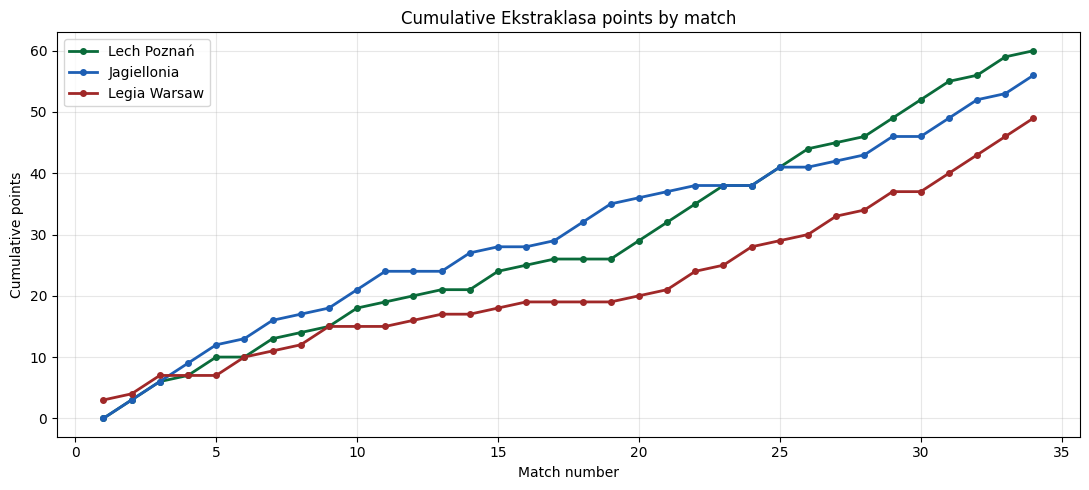

In [44]:
# Load all three match logs at once
logs = {team: load_match_log(key) for team, key in TEAM_FILE.items()}

fig, ax = plt.subplots(figsize=(11, 5))

colors = {
    "Lech Poznań": "#0a6b3a",
    "Jagiellonia": "#1e5fb4",
    "Legia Warsaw": "#a02828",
}

for team, df in logs.items():
    ax.plot(df["matchweek"], df["cum_pts"],
            marker="o", markersize=4, linewidth=2,
            color=colors[team], label=team)

ax.set_title("Cumulative Ekstraklasa points by match")
ax.set_xlabel("Match number")
ax.set_ylabel("Cumulative points")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What the trajectory shows

Three distinct phases:

1. **Matches 1-10**: Jaga opens the strongest. Lech actually loses the opener 1-4 to Cracovia (visible as a flat point 1 for Lech). Legia keeps pace until match 9.
2. **Matches 11-24**: Jaga leads the league for about 13 matches with a peak gap of 6 points over Lech around match 11. Lech and Jaga run parallel mid-season. Legia falls off the top-tier pace.
3. **Matches 25-34**: Lech catches Jaga by match 25, then pulls away decisively in the final 10. Jaga plateaus. Legia clearly behind but stable.

Cumulative points hide momentum. Form curves below show *when* each club went hot or cold.

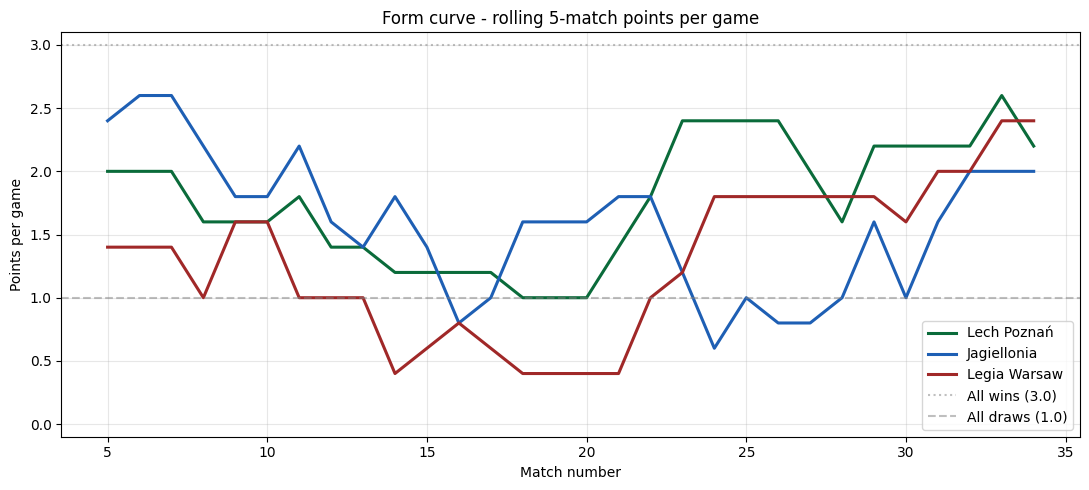

In [45]:
WINDOW = 5

fig, ax = plt.subplots(figsize=(11, 5))

for team, df in logs.items():
    rolling_ppg = df["Pts"].rolling(WINDOW, min_periods=WINDOW).mean()
    ax.plot(df["matchweek"], rolling_ppg,
            linewidth=2.2, color=colors[team], label=team)

# Reference lines
ax.axhline(3, color="grey", linestyle=":", alpha=0.5, label="All wins (3.0)")
ax.axhline(1, color="grey", linestyle="--", alpha=0.5, label="All draws (1.0)")

ax.set_title(f"Form curve - rolling {WINDOW}-match points per game")
ax.set_xlabel("Match number")
ax.set_ylabel("Points per game")
ax.set_ylim(-0.1, 3.1)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Form curve narrative

The curves reveal the season's crises and surges in a way the standings cannot:

- **Legia's crisis (matches 14-20)**: rolling form drops to 0.4 points per game - two points out of fifteen. The deepest single 5-match window in the trio.
- **Lech's mid-season slump (matches 17-20)**: 1.0 PPG. The eventual champion almost surrendered the title race in late autumn.
- **Jaga's crash (matches 23-24)**: from 1.8 PPG down to 0.6 PPG. This is where they lost the league.
- **Lech's title surge (matches 22-26)**: jumps from 1.0 to 2.4 PPG. The championship-defining phase.
- **Legia's late surge**: 2.4 PPG by the closing matches - too late to chase Europe but shows the squad re-found a working shape.



## 3. Autumn vs Spring split

Ekstraklasa splits on the winter break. Comparing first half (matches 1-17) vs second half (18-34) shows whether each club improved or regressed after the break.

In [46]:
def split_season(df: pd.DataFrame) -> pd.DataFrame:
    half = ["Autumn" if mw <= 17 else "Spring" for mw in df["matchweek"]]
    df = df.assign(half=half)
    agg = (df.groupby("half")
             .agg(MP=("Pts", "size"),
                  W=("Result", lambda s: (s == "W").sum()),
                  D=("Result", lambda s: (s == "D").sum()),
                  L=("Result", lambda s: (s == "L").sum()),
                  GF=("GF", "sum"),
                  GA=("GA", "sum"),
                  Pts=("Pts", "sum"))
             .reset_index())
    agg["PPG"] = (agg["Pts"] / agg["MP"]).round(2)
    return agg

rows = []
for team, df in logs.items():
    s = split_season(df)
    s.insert(0, "Squad", team)
    rows.append(s)

split_table = pd.concat(rows, ignore_index=True)
split_table

,Squad,half,MP,W,D,L,GF,GA,Pts,PPG
0,Lech Poznań,Autumn,17,6,8,3,29,26,26,1.53
1,Lech Poznań,Spring,17,10,4,3,33,19,34,2.00
2,Jagiellonia,Autumn,17,8,5,4,29,21,29,1.71
3,Jagiellonia,Spring,17,7,6,4,27,20,27,1.59
4,Legia Warsaw,Autumn,17,4,7,6,19,20,19,1.12
5,Legia Warsaw,Spring,17,8,6,3,23,17,30,1.76


### Autumn vs Spring takeaways

- **Lech improved sharply** (1.53 → 2.00 PPG, +31%). The spring half is the championship phase - 10 wins out of 17, only 19 goals conceded across the full half. This is the title-winning shape.
- **Jagiellonia was the autumn leader** (1.71 PPG, 29 points - more than Lech's 26). Then declined slightly in spring (1.59 PPG, 27 points). The "lost the league" moment happens *after* the break.
- **Legia's spring resurgence is the most extreme** (1.12 → 1.76 PPG, +57%). Their autumn was the worst stretch of the season for any top-six club - 4 wins from 17 matches. The spring 1.76 PPG is the third-best in the league. Recovery came too late to chase Europe.

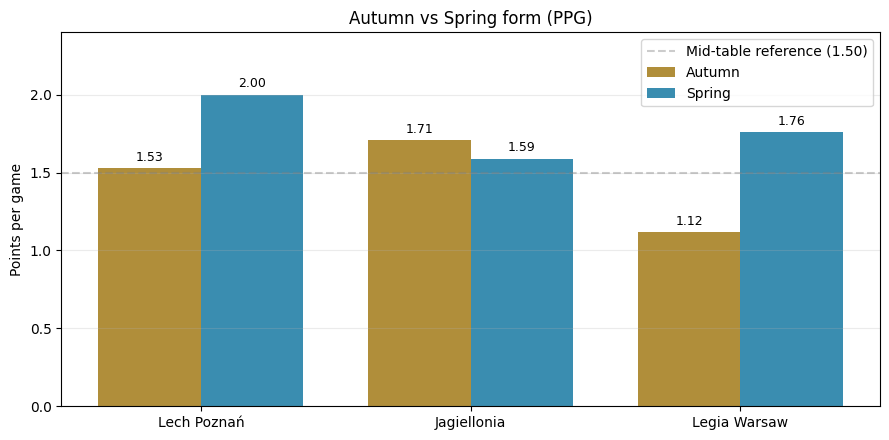

In [47]:
fig, ax = plt.subplots(figsize=(9, 4.5))

pivot = split_table.pivot(index="Squad", columns="half", values="PPG")
pivot = pivot[["Autumn", "Spring"]]  # order columns
pivot = pivot.loc[list(TARGETS.keys())]  # order rows by our colors dict

x = np.arange(len(pivot))
w = 0.38

bars1 = ax.bar(x - w/2, pivot["Autumn"], w, label="Autumn", color="#b08e3a")
bars2 = ax.bar(x + w/2, pivot["Spring"], w, label="Spring", color="#3a8db0")

for bars in (bars1, bars2):
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.set_ylabel("Points per game")
ax.set_title("Autumn vs Spring form (PPG)")
ax.axhline(1.50, color="grey", linestyle="--", alpha=0.4, label="Mid-table reference (1.50)")
ax.legend()
ax.set_ylim(0, 2.4)
ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

## 4. Home vs Away performance

Polish football reputation is that home crowds matter a lot. Lech reports the highest average attendance in the league (31,066), Legia is second (23,490), Jagiellonia smallest of the three (17,818). Does it translate to actual home advantage?

I split each club's match log by venue and compute points per game home vs away.

In [48]:
def home_away_split(df: pd.DataFrame) -> pd.DataFrame:
    agg = (df.groupby("Venue")
             .agg(MP=("Pts", "size"),
                  W=("Result", lambda s: (s == "W").sum()),
                  D=("Result", lambda s: (s == "D").sum()),
                  L=("Result", lambda s: (s == "L").sum()),
                  GF=("GF", "sum"),
                  GA=("GA", "sum"),
                  Pts=("Pts", "sum"))
             .reset_index())
    agg["PPG"] = (agg["Pts"] / agg["MP"]).round(2)
    return agg

rows = []
for team, df in logs.items():
    s = home_away_split(df)
    s.insert(0, "Squad", team)
    rows.append(s)

ha_table = pd.concat(rows, ignore_index=True)
ha_table

,Squad,Venue,MP,W,D,L,GF,GA,Pts,PPG
0,Lech Poznań,Away,17,9,5,3,23,16,32,1.88
1,Lech Poznań,Home,17,7,7,3,39,29,28,1.65
2,Jagiellonia,Away,17,6,8,3,22,17,26,1.53
3,Jagiellonia,Home,17,9,3,5,34,24,30,1.76
4,Legia Warsaw,Away,17,4,7,6,19,25,19,1.12
5,Legia Warsaw,Home,17,8,6,3,23,12,30,1.76


### Home vs Away takeaways

- **Lech has a reverse home advantage**: 1.88 PPG away vs 1.65 PPG home. They scored more at home (39 vs 23) but also conceded much more (29 vs 16). Away matches were tighter and more controlled.
- **Legia is a home fortress**: 12 goals conceded at home in 17 matches (0.71 per match) - elite defensive numbers. Away form collapses (1.12 PPG, 25 conceded) and that single fact mostly explains the missed European place.
- **Jagiellonia has the textbook home advantage**: 1.76 PPG home, 1.53 away. Goals scored split is meaningful (34 home, 22 away).

Worth noting: Lech's high crowds (31k average) did not translate into a stronger home record - the opposite. Legia's home is the most "Polish football cliche" of the three: defensive grind, low-scoring 1-0/2-0 wins.

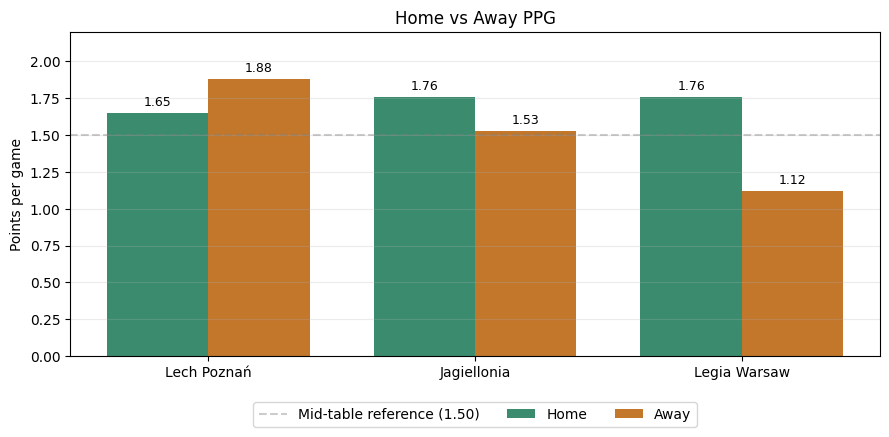

In [49]:
fig, ax = plt.subplots(figsize=(9, 4.5))

pivot_ha = ha_table.pivot(index="Squad", columns="Venue", values="PPG")
pivot_ha = pivot_ha[["Home", "Away"]]
pivot_ha = pivot_ha.loc[list(TARGETS.keys())]

x = np.arange(len(pivot_ha))
w = 0.38

b1 = ax.bar(x - w/2, pivot_ha["Home"], w, label="Home", color="#3b8c6e")
b2 = ax.bar(x + w/2, pivot_ha["Away"], w, label="Away", color="#c2772b")

for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(pivot_ha.index)
ax.set_ylabel("Points per game")
ax.set_title("Home vs Away PPG")
ax.axhline(1.50, color="grey", linestyle="--", alpha=0.4, label="Mid-table reference (1.50)")
ax.set_ylim(0, 2.2)
ax.grid(True, alpha=0.25, axis="y")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.show()

## 5. Goals distribution

### How decisive were the results?

Group every match by goal margin into five buckets. Big wins / heavy losses tell us whether a club steamrolled opponents or grinded tight results.

In [50]:
def bucket_margin(gd: int) -> str:
    if gd >= 3:  return "Big win (+3 or more)"
    if gd >= 1:  return "Win (+1 or +2)"
    if gd == 0:  return "Draw"
    if gd >= -2: return "Loss (-1 or -2)"
    return "Heavy loss (-3 or worse)"

buckets_order = [
    "Big win (+3 or more)",
    "Win (+1 or +2)",
    "Draw",
    "Loss (-1 or -2)",
    "Heavy loss (-3 or worse)",
]

frames = []
for team, df in logs.items():
    gd = df["GF"] - df["GA"]
    counts = gd.apply(bucket_margin).value_counts().reindex(buckets_order, fill_value=0)
    frames.append(counts.rename(team))

dist = pd.concat(frames, axis=1).T
dist

,Big win (+3 or more),Win (+1 or +2),Draw,Loss (-1 or -2),Heavy loss (-3 or worse)
Lech Poznań,4,12,12,5,1
Jagiellonia,4,11,11,6,2
Legia Warsaw,2,10,13,8,1


### Result-margin takeaways

- **Lech is the most decisive of the three**: 4 big wins and only 1 heavy loss. The champion finished games when they had the edge.
- **Jagiellonia is volatile**: same 4 big wins as Lech, but also the most heavy losses (2). When they were good they crushed, when they were bad they got crushed.
- **Legia rarely loses badly but also rarely wins big**: 2 big wins (lowest of three) and 8 narrow losses (highest). Always in the game, never closing it out. Matches the missing-striker story - Rajovic top scored with only 6 goals.

All three sit at 11-13 draws - the high draw rate is an Ekstraklasa feature, not a target-club quirk.

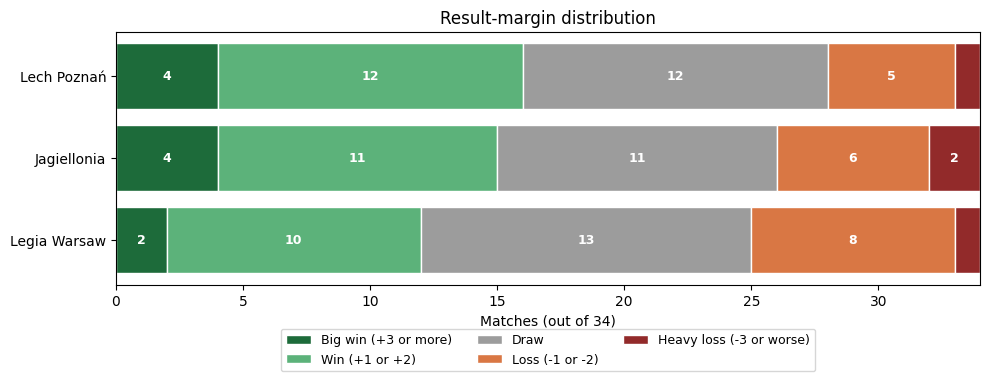

In [51]:
fig, ax = plt.subplots(figsize=(10, 4))

bucket_colors = ["#1d6b3a", "#5cb27a", "#9c9c9c", "#d97744", "#922a2a"]

left = np.zeros(len(dist))
for col, color in zip(buckets_order, bucket_colors):
    vals = dist[col].values
    bars = ax.barh(dist.index, vals, left=left, color=color, label=col, edgecolor="white")
    # Label segments large enough to fit
    for i, v in enumerate(vals):
        if v >= 2:
            ax.text(left[i] + v/2, i, str(v), va="center", ha="center",
                    color="white", fontsize=9, fontweight="bold")
    left += vals

ax.set_xlim(0, 34)
ax.set_xlabel("Matches (out of 34)")
ax.set_title("Result-margin distribution")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=9)
ax.invert_yaxis()
plt.tight_layout()

### Clean sheets and failed-to-score

Four numbers per club:

- **Clean sheets**: matches with 0 conceded - the defensive ceiling.
- **Failed to score**: matches with 0 scored - the attacking floor.
- **GF per match**: average goals for.
- **GA per match**: average goals against.

In [52]:
rows = []
for team, df in logs.items():
    n = len(df)
    rows.append({
        "Squad": team,
        "Clean sheets": int((df["GA"] == 0).sum()),
        "Failed to score": int((df["GF"] == 0).sum()),
        "GF/match": round(df["GF"].mean(), 2),
        "GA/match": round(df["GA"].mean(), 2),
        "BTS %": round(((df["GF"] > 0) & (df["GA"] > 0)).mean() * 100, 1),
    })

defense_attack = pd.DataFrame(rows)
defense_attack

,Squad,Clean sheets,Failed to score,GF/match,GA/match,BTS %
0,Lech Poznań,10,4,1.82,1.32,67.6
1,Jagiellonia,10,6,1.65,1.21,64.7
2,Legia Warsaw,11,7,1.24,1.09,55.9


## 6. Head-to-head: the six direct matches

Each pair plays twice. With three target clubs that gives six direct matches across the season. They are usually where seasons swing.

In [53]:
# First, verify how opponents are spelled in the match logs
for team, df in logs.items():
    opps = df["Opponent"].unique()
    targets_seen = [t for t in TARGETS if any(t.split()[0] in o for o in opps)]
    print(f"{team:<15} unique opponents in log: {len(opps)}")
    print(f"  target opponents found: {targets_seen}")

Lech Poznań     unique opponents in log: 17
  target opponents found: ['Lech Poznań', 'Jagiellonia', 'Legia Warsaw']
Jagiellonia     unique opponents in log: 17
  target opponents found: ['Lech Poznań', 'Legia Warsaw']
Legia Warsaw    unique opponents in log: 17
  target opponents found: ['Lech Poznań', 'Jagiellonia']


In [54]:
TARGET_NAMES = list(TARGETS.keys())

h2h_rows = []
for team, df in logs.items():
    home = df[df["Venue"] == "Home"]
    for opp in TARGET_NAMES:
        if opp == team:
            continue
        matches = home[home["Opponent"] == opp]
        for _, row in matches.iterrows():
            h2h_rows.append({
                "Date": row["Date"].date(),
                "Home": team,
                "Away": opp,
                "Score": f"{int(row['GF'])}-{int(row['GA'])}",
                "Result": row["Result"],
                "Poss": row.get("Poss", None),
                "Attendance": row.get("Attendance", None),
            })

h2h = pd.DataFrame(h2h_rows).sort_values("Date").reset_index(drop=True)
h2h

,Date,Home,Away,Score,Result,Poss,Attendance
0,2025-09-24,Legia Warsaw,Jagiellonia,0-0,D,51,24884
1,2025-09-28,Lech Poznań,Jagiellonia,2-2,D,53,35299
2,2025-10-26,Legia Warsaw,Lech Poznań,0-0,D,48,26498
3,2026-03-01,Jagiellonia,Legia Warsaw,2-2,D,57,20048
4,2026-04-04,Jagiellonia,Lech Poznań,0-0,D,49,19789
5,2026-04-26,Lech Poznań,Legia Warsaw,4-0,W,67,40810


### What the head-to-heads actually decided

- **Five of the six matches were draws**. Three of them 0-0 (Legia-Jaga, Legia-Lech, Jaga-Lech), two of them 2-2 (Lech-Jaga, Jaga-Legia).
- **One match decided everything: Lech 4-0 Legia on 2026-04-26** - the season's biggest attendance (40,810) and the matchday that confirmed the title race was over. Legia's worst single result among the trio's six clashes.
- **Points from head-to-heads** (out of 12 possible): Lech 6, Jagiellonia 4, Legia 3. Even the points balance is mostly cancelled out by mutual draws.
- **Jaga never won** against either of the other two. Three draws and one loss (the away 0-0 at Lech does count as a draw).

Take-away: the three biggest clubs neutralised each other across the season. The title was won outside of these direct meetings, by accumulating wins elsewhere.

In [55]:
# Aggregate H2H points per team
points = {team: 0 for team in TARGET_NAMES}
for _, r in h2h.iterrows():
    if r["Result"] == "W":
        points[r["Home"]] += 3
    elif r["Result"] == "D":
        points[r["Home"]] += 1
        points[r["Away"]] += 1
    else:
        points[r["Away"]] += 3

h2h_summary = pd.DataFrame([
    {"Squad": t, "H2H points (out of 12)": p, "Share %": round(p / 12 * 100, 1)}
    for t, p in points.items()
])
h2h_summary

,Squad,H2H points (out of 12),Share %
0,Lech Poznań,6,50.0
1,Jagiellonia,4,33.3
2,Legia Warsaw,3,25.0


## 7. Key players

The standings already showed top scorers per team. Below the top line: who played the minutes, who created the goals, how the goalkeepers compared.

The FBref player tables use two-row headers. Loading with `header=[0, 1]` and flattening makes them easier to work with.

In [56]:
def flatten_player_cols(df: pd.DataFrame) -> pd.DataFrame:
    new_cols = []
    for c in df.columns:
        top, sub = c
        if str(top).startswith("Unnamed"):
            new_cols.append(sub)
        elif "Per 90" in str(top):
            new_cols.append(f"{sub}_per90")
        else:
            new_cols.append(sub)
    df = df.copy()
    df.columns = new_cols
    # Drop summary rows like "Squad Total" / "Opponent Total"
    df = df[~df["Player"].astype(str).str.contains("Total", na=False)]
    return df

def load_player_standard(team_key: str) -> pd.DataFrame:
    df = pd.read_csv(f'{DATA}/{team_key}_player_standard.csv', header=[0, 1])
    return flatten_player_cols(df).reset_index(drop=True)

# Quick check on Jaga
jaga_players = load_player_standard("jagiellonia")
print(f'shape: {jaga_players.shape}')
print(f'columns: {jaga_players.columns.tolist()}')
jaga_players.head(3)

shape: (41, 22)
columns: ['Player', 'Nation', 'Pos', 'Age', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'Gls_per90', 'Ast_per90', 'G+A_per90', 'G-PK_per90', 'G+A-PK_per90', 'Matches']


,Player,Nation,Pos,Age,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_per90,Ast_per90,G+A_per90,G-PK_per90,G+A-PK_per90,Matches
0,Jesús Imaz,es ESP,"MF,FW",34,33,32,2784,30.9,13,6,19,13,0,0,5,0,0.42,0.19,0.61,0.42,0.61,Matches
1,Sławomir Abramowicz,pl POL,GK,21,30,30,2700,30.0,0,0,0,0,0,0,1,0,0.00,0.00,0.00,0.00,0.00,Matches
2,Alejandro Pozo Pozo,es ESP,"MF,DF",26,33,28,2414,26.8,2,4,6,2,0,0,4,0,0.07,0.15,0.22,0.07,0.22,Matches


### Top contributors per club (G+A)

Top 5 in each squad by goals + assists. The depth of attack tells us whether goals were spread or concentrated on a single player.

In [57]:
NUMERIC_COLS = [
    "MP", "Starts", "Min", "90s",
    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt", "CrdY", "CrdR",
    "Gls_per90", "Ast_per90", "G+A_per90", "G-PK_per90", "G+A-PK_per90",
]

def flatten_player_cols(df: pd.DataFrame) -> pd.DataFrame:
    new_cols = []
    for c in df.columns:
        top, sub = c
        if str(top).startswith("Unnamed"):
            new_cols.append(sub)
        elif "Per 90" in str(top):
            new_cols.append(f"{sub}_per90")
        else:
            new_cols.append(sub)
    df = df.copy()
    df.columns = new_cols
    # FBref repeats header rows and adds "Squad Total" / "Opponent Total" at the bottom
    df = df[~df["Player"].astype(str).str.contains("Total|Player", na=False, regex=True)]
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.dropna(subset=["Gls"]).reset_index(drop=True)
    return df

def load_player_standard(team_key: str) -> pd.DataFrame:
    df = pd.read_csv(f'{DATA}/{team_key}_player_standard.csv', header=[0, 1])
    return flatten_player_cols(df)

jaga_players = load_player_standard("jagiellonia")
print(f'shape: {jaga_players.shape}')
jaga_players.head(3)

shape: (32, 22)


,Player,Nation,Pos,Age,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_per90,Ast_per90,G+A_per90,G-PK_per90,G+A-PK_per90,Matches
0,Jesús Imaz,es ESP,"MF,FW",34,33.0,32.0,2784.0,30.9,13.0,6.0,19.0,13.0,0.0,0.0,5.0,0.0,0.42,0.19,0.61,0.42,0.61,Matches
1,Sławomir Abramowicz,pl POL,GK,21,30.0,30.0,2700.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.00,0.00,0.00,0.00,0.00,Matches
2,Alejandro Pozo Pozo,es ESP,"MF,DF",26,33.0,28.0,2414.0,26.8,2.0,4.0,6.0,2.0,0.0,0.0,4.0,0.0,0.07,0.15,0.22,0.07,0.22,Matches


In [58]:
def top_contributors(team_key: str, n: int = 5) -> pd.DataFrame:
    df = load_player_standard(team_key)
    cols = ["Player", "Pos", "Age", "MP", "Min", "Gls", "Ast", "G+A"]
    out = df.sort_values("G+A", ascending=False).head(n)[cols].reset_index(drop=True)
    return out

for team, key in TEAM_FILE.items():
    print(f"\n=== {team} ===")
    print(top_contributors(key).to_string(index=False))


=== Lech Poznań ===
            Player   Pos Age   MP    Min  Gls  Ast  G+A
      Mikael Ishak    FW  32 31.0 2419.0 16.0  5.0 21.0
Luis Enrique Palma MF,FW  25 31.0 1653.0 10.0  6.0 16.0
    Ali Gholizadeh    MF  29 19.0 1131.0  6.0  4.0 10.0
     Leo Bengtsson    MF  27 33.0 2064.0  6.0  3.0  9.0
      Joel Pereira    DF  28 31.0 2347.0  2.0  5.0  7.0

=== Jagiellonia ===
             Player   Pos Age   MP    Min  Gls  Ast  G+A
     Afimico Pululu    FW  26 33.0 2352.0 15.0  5.0 20.0
         Jesús Imaz MF,FW  34 33.0 2784.0 13.0  6.0 19.0
Alejandro Pozo Pozo MF,DF  26 33.0 2414.0  2.0  4.0  6.0
      Sergio Lozano    MF  26 14.0  607.0  3.0  2.0  5.0
     Bernardo Vital    DF  24 27.0 2210.0  3.0  1.0  4.0

=== Legia Warsaw ===
           Player   Pos Age   MP    Min  Gls  Ast  G+A
   Mileta Rajovic    FW  26 32.0 2282.0  6.0  0.0  6.0
    Rafał Adamski FW,MF  23 13.0  887.0  4.0  2.0  6.0
   Juergen Elitim    MF  26 25.0 1910.0  2.0  3.0  5.0
Jean-Pierre Nsame    FW  32 10.0  562.

### Attack-depth takeaways

- **Lech: deep, multi-source attack.** Ishak leads with 16 goals but Palma adds 10 more, Gholizadeh another 6. Top 3 players combined: 32 goals + 15 assists.
- **Jagiellonia: a two-man front.** Pululu (15G/5A) and Imaz (13G/6A) jointly produced 28 goals - exactly 50% of the team's 56 league goals. After those two there is a sharp drop to single-digit G+A. Lose either of them and the entire attack profile changes.
- **Legia: no attacking leader at all.** Top scorer Rajovic finished with 6 goals and 0 assists. The 2nd and 3rd top contributors combined for only 9 goals. With this striker output, finishing 6th was almost mathematically forced.

Goals scored across the season: Lech 62, Jagiellonia 56, Legia 42. The standings number reflects this depth gap directly.

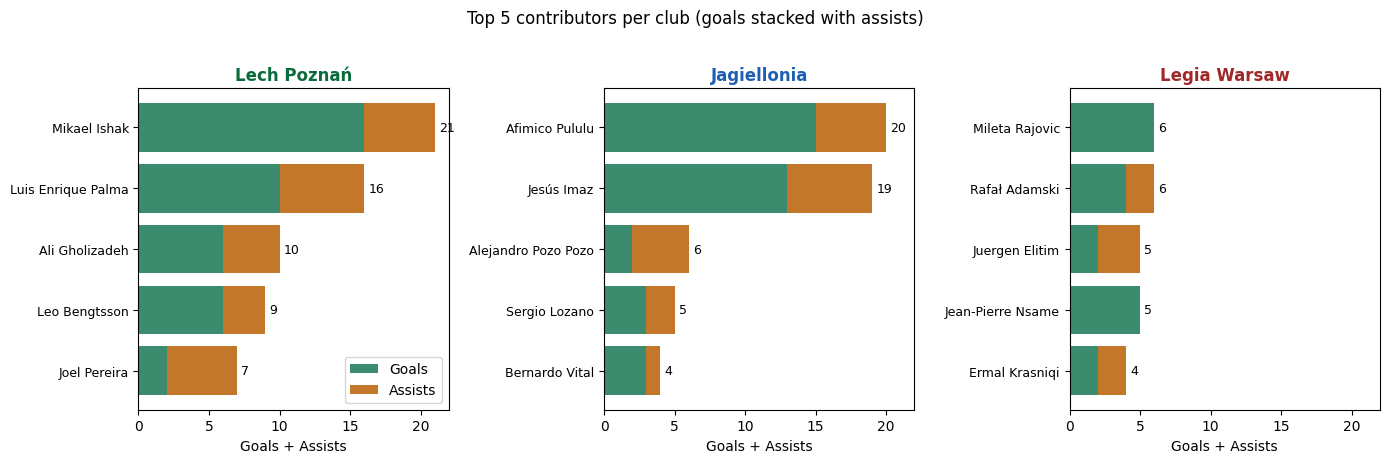

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, (team, key) in zip(axes, TEAM_FILE.items()):
    top = top_contributors(key, n=5)
    pos = np.arange(len(top))
    ax.barh(pos, top["Gls"], color="#3b8c6e", label="Goals")
    ax.barh(pos, top["Ast"], left=top["Gls"], color="#c2772b", label="Assists")

    ax.set_yticks(pos)
    ax.set_yticklabels(top["Player"], fontsize=9)
    ax.invert_yaxis()
    ax.set_title(team, color=colors[team], fontweight="bold")
    ax.set_xlabel("Goals + Assists")
    ax.set_xlim(0, 22)

    for i, (g, a) in enumerate(zip(top["Gls"], top["Ast"])):
        ax.text(g + a + 0.3, i, f"{int(g + a)}", va="center", fontsize=9)

axes[0].legend(loc="lower right")
plt.suptitle("Top 5 contributors per club (goals stacked with assists)", y=1.02)
plt.tight_layout()
plt.show()

### Starting goalkeepers

Each club had one clear starter. The standings listed Bartosz Mrozek (Lech), Sławomir Abramowicz (Jagiellonia), Kacper Tobiasz (Legia). I extract the goalkeeping stats for whichever GK played the most minutes per club.

In [60]:
gk_rows = []
for team, key in TEAM_FILE.items():
    df = load_gk(key)
    df_sorted = df.sort_values("Min", ascending=False)
    for _, gk in df_sorted.iterrows():
        if pd.notna(gk["Min"]) and gk["Min"] >= 200:
            gk_rows.append({
                "Team": team,
                "GK": gk["Player"],
                "Min": int(gk["Min"]),
                "GA": int(gk["GA"]),
                "GA/90": gk["GA90"],
                "SoTA": int(gk["SoTA"]),
                "Saves": int(gk["Saves"]),
                "Save%": gk["Save%"],
                "CS": int(gk["CS"]),
                "CS%": gk["CS%"],
            })

gk_compare = pd.DataFrame(gk_rows)
gk_compare

,Team,GK,Min,GA,GA/90,SoTA,Saves,Save%,CS,CS%
0,Lech Poznań,Bartosz Mrozek,2970,44,1.33,125,86,67.2,10,30.3
1,Jagiellonia,Sławomir Abramowicz,2700,36,1.20,122,92,74.6,9,30.0
2,Jagiellonia,Miłosz Piekutowski,360,5,1.25,23,18,78.3,1,25.0
3,Legia Warsaw,Kacper Tobiasz,1896,26,1.23,62,40,66.1,6,28.6
4,Legia Warsaw,Otto Hindrich,1164,11,0.85,44,33,75.0,6,46.2


### Goalkeeper takeaways

- **Bartosz Mrozek (Lech, 2970 min)** - the workhorse. Conceded the most goals of any starter (44) and faced the most shots on target (125). Save% 67.2 is mid-tier. Lech's open style asks a lot of him.
- **Sławomir Abramowicz (Jaga, 2700 min)** - the most reliable starter with a 74.6% save rate and 9 clean sheets. Jaga's defensive numbers (1.21 GA/match in the standings) sit largely on him.
- **Legia rotated two goalkeepers**: Kacper Tobiasz played 1896 min (about 21 matches) with average numbers (GA/90 1.23, Save% 66.1). Otto Hindrich played 1164 min (about 13 matches) with **GA/90 0.85, Save% 75.0, and clean sheets in 46% of his appearances** - championship-level goalkeeping in the backup minutes. The team's defensive identity (12 conceded at home) partly comes from this rotation.

The Hindrich finding is the kind of insight that disappears if you only look at the headline goalkeeper per club. Pulling the depth chart matters.

### Goalkeeper rotation and team results

The player_goalkeeping table includes team wins, draws and losses *in the matches that goalkeeper started*. That lets me ask the analytical question directly: did Legia perform better with Hindrich or Tobiasz?

In [61]:
gk_rows = []
for team, key in TEAM_FILE.items():
    df = load_gk(key)
    df_sorted = df.sort_values("Min", ascending=False)
    for _, gk in df_sorted.iterrows():
        if pd.notna(gk["Min"]) and gk["Min"] >= 200:
            w, d, l = int(gk["W"]), int(gk["D"]), int(gk["L"])
            mp = w + d + l
            pts = w * 3 + d
            gk_rows.append({
                "Team": team,
                "GK": gk["Player"],
                "MP": mp,
                "W": w,
                "D": d,
                "L": l,
                "Pts": pts,
                "PPG": round(pts / mp, 2) if mp else 0,
                "GA/90": gk["GA90"],
                "Save%": gk["Save%"],
                "CS%": gk["CS%"],
            })

gk_compare = pd.DataFrame(gk_rows)
gk_compare

,Team,GK,MP,W,D,L,Pts,PPG,GA/90,Save%,CS%
0,Lech Poznań,Bartosz Mrozek,33,15,12,6,57,1.73,1.33,67.2,30.3
1,Jagiellonia,Sławomir Abramowicz,30,13,11,6,50,1.67,1.20,74.6,30.0
2,Jagiellonia,Miłosz Piekutowski,4,2,0,2,6,1.50,1.25,78.3,25.0
3,Legia Warsaw,Kacper Tobiasz,21,4,9,8,21,1.00,1.23,66.1,28.6
4,Legia Warsaw,Otto Hindrich,13,8,4,1,28,2.15,0.85,75.0,46.2


### Goalkeeper rotation breakdown

Splitting Legia's season by which goalkeeper started:

- **Tobiasz** - 21 matches, 4W/9D/8L, 1.00 PPG
- **Hindrich** - 13 matches, 8W/4D/1L, 2.15 PPG

For reference: Lech's starter Mrozek delivered 1.73 PPG over 33 matches and Jagiellonia's Abramowicz 1.67 PPG over 30 matches.

The split lines up with the autumn-spring transformation seen earlier. Autumn 1.12 PPG ≈ Tobiasz's period, spring 1.76 PPG ≈ Hindrich's period. Legia also went through three coaching changes in the season, which is likely tied to the same switch.

What the data does not let us check is causation - whether Hindrich was the reason for the form change, or just played during a wider tactical reset. The numbers correlate strongly but stop short of proof.

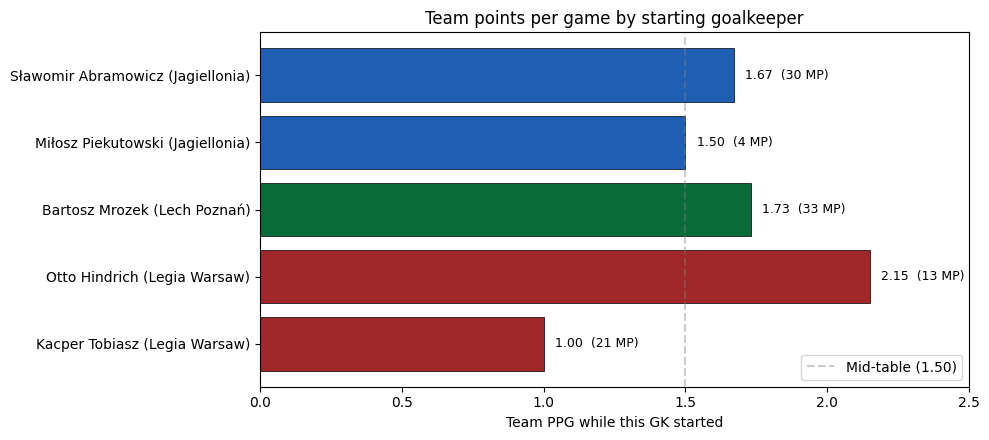

In [62]:
fig, ax = plt.subplots(figsize=(10, 4.5))

gk_sorted = gk_compare.sort_values(["Team", "PPG"], ascending=[True, False]).reset_index(drop=True)
bar_colors = [colors[t] for t in gk_sorted["Team"]]
ax.barh(gk_sorted["GK"] + " (" + gk_sorted["Team"] + ")", gk_sorted["PPG"],
        color=bar_colors, edgecolor="black", linewidth=0.5)

for i, (ppg, mp) in enumerate(zip(gk_sorted["PPG"], gk_sorted["MP"])):
    ax.text(ppg + 0.04, i, f"{ppg:.2f}  ({mp} MP)", va="center", fontsize=9)

ax.axvline(1.50, color="grey", linestyle="--", alpha=0.4, label="Mid-table (1.50)")
ax.set_xlim(0, 2.5)
ax.set_xlabel("Team PPG while this GK started")
ax.set_title("Team points per game by starting goalkeeper")
ax.invert_yaxis()
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 9. Tactical fingerprint - radar vs league average

I aggregate six metrics from every club's match log (all 18 squads), then plot the three target clubs against the league average. Higher on the radar means more of that metric - I flip the defensive metric so higher is still "better".

Metrics:
1. Goals scored per match
2. Goals conceded per match (inverted: low GA = high radar)
3. Win rate
4. Clean sheet rate
5. Possession (average match possession %)
6. Big-win rate (matches won by 3+ goals)

In [63]:
import os

# Load every team's match log
all_teams = [f.replace("_match_log.csv", "") for f in os.listdir(DATA) if f.endswith("_match_log.csv")]
all_teams = [t for t in all_teams if t != "league"]  # drop if present
print(f"teams found: {len(all_teams)}")

def load_team_log(key: str) -> pd.DataFrame:
    df = pd.read_csv(f"{DATA}/{key}_match_log.csv")
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"])
    df = df[df["Comp"] == "Ekstraklasa"]
    for c in ["GF", "GA", "Poss"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df["Pts"] = df["Result"].map({"W": 3, "D": 1, "L": 0})
    return df

def metrics(df):
    n = len(df)
    return {
        "Goals/match":    df["GF"].sum() / n,
        "Defence (1/GA)": 1 / (df["GA"].sum() / n),   # invert so higher = better
        "Win rate":       (df["Result"] == "W").mean(),
        "Clean sheet %":  (df["GA"] == 0).mean(),
        "Possession":     df["Poss"].mean() / 100,
        "Big-win rate":   ((df["GF"] - df["GA"]) >= 3).mean(),
    }

rows = []
for t in all_teams:
    try:
        m = metrics(load_team_log(t))
        m["team_key"] = t
        rows.append(m)
    except Exception as e:
        print(f"skip {t}: {e}")

league_df = pd.DataFrame(rows).set_index("team_key")
league_df.round(3).head()

teams found: 18


,Goals/match,Defence (1/GA),Win rate,Clean sheet %,Possession,Big-win rate
team_key,,,,,,
gks_katowice,1.500,0.756,0.412,0.265,0.465,0.118
pogon_szczecin,1.382,0.694,0.382,0.206,0.520,0.088
rakow,1.500,0.850,0.471,0.294,0.540,0.118
lech,1.824,0.756,0.471,0.294,0.576,0.118
jagiellonia,1.647,0.829,0.441,0.294,0.581,0.118


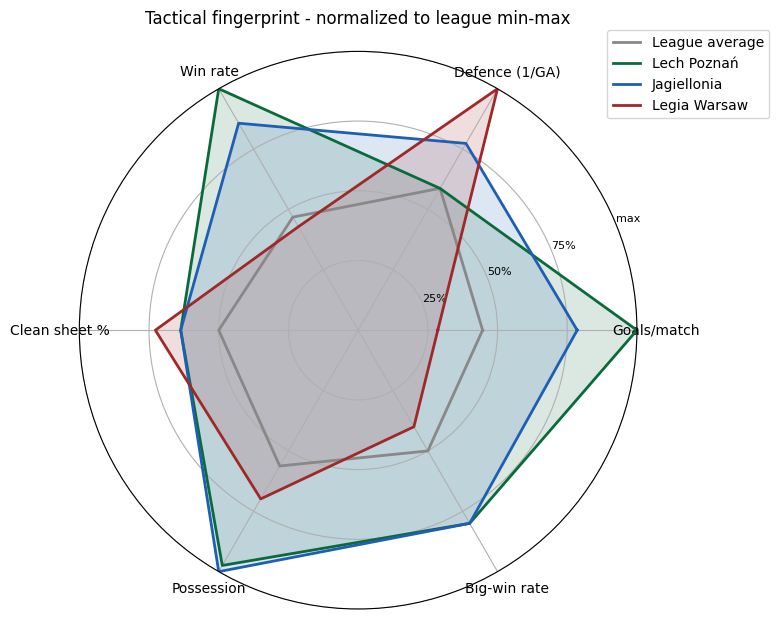

In [64]:
metric_cols = ["Goals/match", "Defence (1/GA)", "Win rate", "Clean sheet %", "Possession", "Big-win rate"]

# Normalize each metric to 0-1 across the 18 teams (min-max within league)
norm = league_df[metric_cols].copy()
for col in metric_cols:
    lo, hi = norm[col].min(), norm[col].max()
    norm[col] = (norm[col] - lo) / (hi - lo) if hi > lo else 0.5

# League average (in normalized space) is just the mean of each column
league_avg = norm.mean()

# Pull our three target rows
norm_targets = norm.loc[[TEAM_FILE[t] for t in TARGET_NAMES]]
norm_targets.index = TARGET_NAMES

# Build the radar
angles = np.linspace(0, 2 * np.pi, len(metric_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

def plot_polygon(values, label, color, fill_alpha=0.15):
    vals = list(values) + [values[0]]
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=fill_alpha)

plot_polygon(league_avg.values, "League average", "#888888", fill_alpha=0.0)
for team in TARGET_NAMES:
    plot_polygon(norm_targets.loc[team].values, team, colors[team])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_cols, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "max"], fontsize=8)
ax.set_ylim(0, 1)
ax.set_title("Tactical fingerprint - normalized to league min-max", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05))
plt.tight_layout()
plt.show()

### Tactical fingerprint takeaways

The three clubs split clearly into distinct profiles:

- **Lech: attacking.** Tops the league in Goals/match, Win rate and Big-win rate. Defence is just average. The title came from outscoring opponents, not stopping them.
- **Jagiellonia: balanced all-rounder.** Slightly below Lech on attack but ahead on possession (highest in the league) and equally strong defensive numbers. The "tidiest" profile of the three.
- **Legia: defensive grinder.** Tops the league in Defence and Clean Sheet rate. Bottom of the three on Goals/match and Big-win rate. The shape matches every other Legia number from the season - elite back line, no finisher up front.

League average sits inside all three polygons, confirming the trio sit clearly above mid-table on most axes.

## 10. Player profile analysis

Two analyses on the same player set:

1. **Pizza chart for Pululu** - percentile rank against every Ekstraklasa forward who played 1000+ minutes.
2. **KMeans clustering of forwards** - splits the league's strikers into style groups and shows where Pululu sits.

Both need a combined view of standard stats + shooting stats for every forward across the league.

In [74]:
def load_player_shooting(team_key: str) -> pd.DataFrame:
    df = pd.read_csv(f"{DATA}/{team_key}_player_shooting.csv", header=[0, 1])
    new_cols = []
    for top, sub in df.columns:
        if str(top).startswith("Unnamed"):
            new_cols.append(sub)
        else:
            new_cols.append(sub)
    df = df.copy()
    df.columns = new_cols
    df = df[~df["Player"].astype(str).str.contains("Total|Player", na=False, regex=True)]
    for col in ["90s", "Gls", "Sh", "SoT", "SoT%", "Sh/90", "SoT/90", "G/Sh", "G/SoT"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


all_keys = sorted({f.replace("_player_standard.csv", "")
                   for f in os.listdir(DATA) if f.endswith("_player_standard.csv")})

std_frames, sht_frames = [], []
for key in all_keys:
    try:
        std = load_player_standard(key).assign(team_key=key)
        sht = load_player_shooting(key).assign(team_key=key)
        std_frames.append(std)
        sht_frames.append(sht)
    except Exception as e:
        print(f"skip {key}: {e}")

std_all = pd.concat(std_frames, ignore_index=True)
sht_all = pd.concat(sht_frames, ignore_index=True)

std_keep = std_all[["team_key", "Player", "Pos", "Age", "Min", "90s",
                    "Gls", "Ast", "G+A", "G-PK", "PK", "PKatt",
                    "Gls_per90", "Ast_per90", "G+A_per90",
                    "G-PK_per90", "G+A-PK_per90"]]
sht_keep = sht_all[["team_key", "Player", "Sh", "SoT", "SoT%", "Sh/90", "SoT/90", "G/Sh"]]

players = std_keep.merge(sht_keep, on=["team_key", "Player"], how="left")

forwards = players[
    players["Pos"].astype(str).str.contains("FW", na=False) &
    (players["Min"] >= 1000)
].reset_index(drop=True)

print(f"All players: {len(players)}")
print(f"Forwards with 1000+ minutes: {len(forwards)}")

All players: 553
Forwards with 1000+ minutes: 75


### Pizza chart - Pululu vs the league

For each per-90 metric I compute Pululu's percentile rank against the other forwards. 100% means he leads the league on that metric, 0% means he is bottom.

The shape tells us his profile: is he a high-volume shooter who misses, a clinical finisher with few attempts, a goal-and-assist creator?

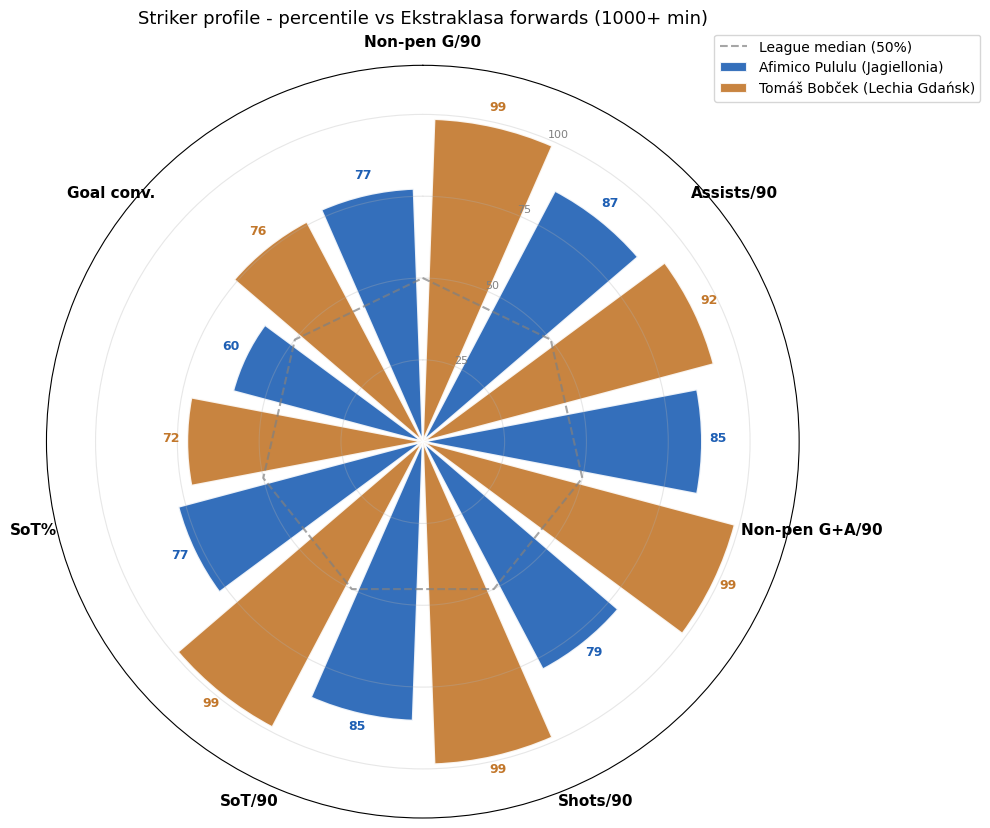

In [73]:
PULULU = "Afimico Pululu"
BENCHMARK = "Tomáš Bobček"

pizza_metrics = [
    ("G-PK_per90",   "Non-pen G/90"),
    ("Ast_per90",    "Assists/90"),
    ("G+A-PK_per90", "Non-pen G+A/90"),
    ("Sh/90",        "Shots/90"),
    ("SoT/90",       "SoT/90"),
    ("SoT%",         "SoT%"),
    ("G/Sh",         "Goal conv."),
]

def percentiles_for(player_name):
    p = forwards[forwards["Player"] == player_name].iloc[0]
    out = []
    for col, _ in pizza_metrics:
        valid = forwards[col].dropna()
        out.append((valid <= p[col]).mean() * 100 if pd.notna(p[col]) else np.nan)
    return out

pululu_pct = percentiles_for(PULULU)
bench_pct = percentiles_for(BENCHMARK)
labels = [lab for _, lab in pizza_metrics]

angles = np.linspace(0, 2 * np.pi, len(pizza_metrics), endpoint=False)
width = 2 * np.pi / len(pizza_metrics)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

ax.bar(angles - width/4, pululu_pct, width=width * 0.42,
       color="#1e5fb4", edgecolor="white", linewidth=1.5, alpha=0.9,
       label=f"{PULULU} (Jagiellonia)")

ax.bar(angles + width/4, bench_pct, width=width * 0.42,
       color="#c2772b", edgecolor="white", linewidth=1.5, alpha=0.9,
       label=f"{BENCHMARK} (Lechia Gdańsk)")

median_circle = np.full_like(angles, 50)
ax.plot(np.append(angles, angles[0]), np.append(median_circle, 50),
        color="grey", linestyle="--", linewidth=1.5, alpha=0.7, label="League median (50%)")

for i, (angle, label) in enumerate(zip(angles, labels)):
    ax.text(angle, 122, label, ha="center", va="center", fontsize=11, fontweight="bold")
    ax.text(angle - width/4, pululu_pct[i] + 5, f"{pululu_pct[i]:.0f}",
            ha="center", fontsize=9, color="#1e5fb4", fontweight="bold")
    ax.text(angle + width/4, bench_pct[i] + 5, f"{bench_pct[i]:.0f}",
            ha="center", fontsize=9, color="#c2772b", fontweight="bold")

ax.set_ylim(0, 115)
ax.set_yticks([25, 50, 75, 100])
ax.set_yticklabels(["25", "50", "75", "100"], fontsize=8, color="grey")
ax.set_xticks([])
ax.grid(True, alpha=0.3)
ax.set_title("Striker profile - percentile vs Ekstraklasa forwards (1000+ min)",
             pad=30, fontsize=13)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.05))
plt.tight_layout()
plt.show()

In [69]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

cluster_metrics = [
    "Gls_per90", "Ast_per90", "G+A_per90",
    "Sh/90", "SoT/90", "SoT%", "G/Sh",
]

X = forwards[cluster_metrics].dropna()
fw_clean = forwards.loc[X.index].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
fw_clean["cluster"] = kmeans.fit_predict(X_scaled)

# Profile each cluster by mean values
profile = (fw_clean.groupby("cluster")[cluster_metrics + ["Gls", "Ast", "Min"]]
                   .mean()
                   .round(2))
profile["count"] = fw_clean["cluster"].value_counts().sort_index()
profile

,Gls_per90,Ast_per90,G+A_per90,Sh/90,SoT/90,SoT%,G/Sh,Gls,Ast,Min,count
cluster,,,,,,,,,,,
0,0.24,0.09,0.33,2.89,0.87,30.24,0.08,4.36,1.79,1630.79,14
1,0.11,0.11,0.22,1.72,0.43,25.60,0.07,1.95,1.73,1514.05,22
2,0.53,0.18,0.71,3.19,1.41,44.71,0.15,12.15,4.31,2065.54,13
3,0.30,0.09,0.39,1.98,0.82,41.85,0.14,5.46,1.73,1656.69,26


### Cluster profiles

Reading the means:

- **Cluster 0** - high shot volume, low conversion. Strikers who shoot a lot but miss often.
- **Cluster 1** - lowest output everywhere. Mostly rotation forwards and squad players.
- **Cluster 2** - elite output across the board. Highest goals, shots and accuracy. The league's top strikers.
- **Cluster 3** - moderate scoring with the highest accuracy after cluster 2. Efficient finishers playing fewer minutes than the cluster 2 group.

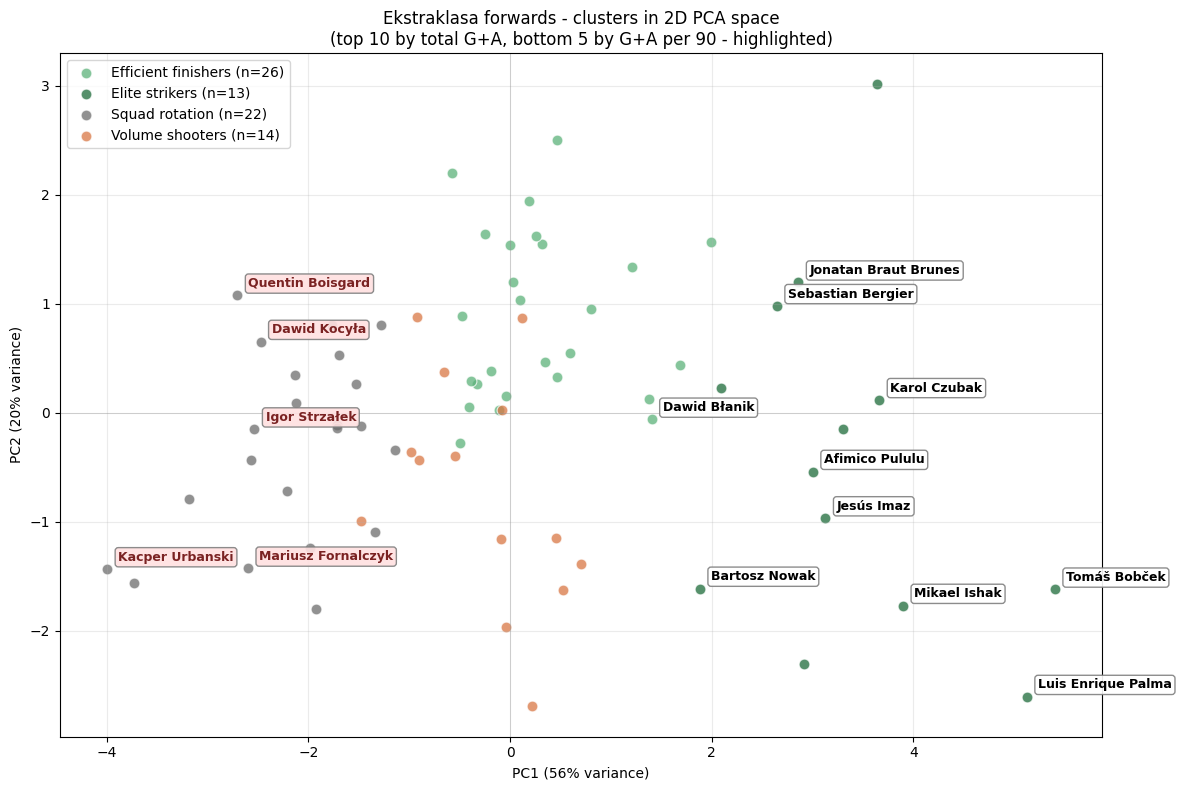


Top 10 by total G+A:
              Player      team_key       cluster_label  Gls  Ast  G+A  Sh/90  G/Sh
        Tomáš Bobček lechia_gdansk      Elite strikers 20.0  6.0 26.0   4.29  0.14
       Bartosz Nowak  gks_katowice      Elite strikers  9.0 12.0 21.0   2.40  0.11
        Karol Czubak  motor_lublin      Elite strikers 18.0  3.0 21.0   3.29  0.16
        Mikael Ishak          lech      Elite strikers 16.0  5.0 21.0   4.09  0.10
      Afimico Pululu   jagiellonia      Elite strikers 15.0  5.0 20.0   2.79  0.12
          Jesús Imaz   jagiellonia      Elite strikers 13.0  6.0 19.0   3.39  0.12
   Sebastian Bergier   widzew_lodz      Elite strikers 14.0  4.0 18.0   2.13  0.19
  Luis Enrique Palma          lech      Elite strikers 10.0  6.0 16.0   4.36  0.13
Jonatan Braut Brunes         rakow      Elite strikers 16.0  0.0 16.0   2.86  0.15
        Dawid Błanik korona_kielce Efficient finishers  9.0  4.0 13.0   2.30  0.15

Bottom 5 by G+A per 90:
            Player      team_key  cluste

In [81]:
cluster_names = {
    0: "Volume shooters",
    1: "Squad rotation",
    2: "Elite strikers",
    3: "Efficient finishers",
}
fw_clean["cluster_label"] = fw_clean["cluster"].map(cluster_names)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fw_clean["pc1"] = X_pca[:, 0]
fw_clean["pc2"] = X_pca[:, 1]

cluster_colors = {
    "Elite strikers":      "#1d6b3a",
    "Efficient finishers": "#5cb27a",
    "Volume shooters":     "#d97744",
    "Squad rotation":      "#6c6c6c",
}

top10 = fw_clean.nlargest(10, "G+A")["Player"].tolist()
bottom5 = fw_clean.nsmallest(5, "G+A_per90")["Player"].tolist()
ANNOTATE = top10 + bottom5

fig, ax = plt.subplots(figsize=(12, 8))
for label, grp in fw_clean.groupby("cluster_label"):
    ax.scatter(grp["pc1"], grp["pc2"],
               s=60, color=cluster_colors[label],
               alpha=0.75, edgecolor="white", linewidth=0.8,
               label=f"{label} (n={len(grp)})")

for name in ANNOTATE:
    row = fw_clean[fw_clean["Player"] == name]
    if not row.empty:
        x, y = row.iloc[0]["pc1"], row.iloc[0]["pc2"]
        is_bottom = name in bottom5
        ax.annotate(name, (x, y), xytext=(8, 6), textcoords="offset points",
                    fontsize=9, fontweight="bold",
                    color="#7a2222" if is_bottom else "black",
                    bbox=dict(boxstyle="round,pad=0.25",
                              fc="#ffe0e0" if is_bottom else "white",
                              ec="grey", alpha=0.9))

ax.axhline(0, color="grey", lw=0.5, alpha=0.4)
ax.axvline(0, color="grey", lw=0.5, alpha=0.4)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% variance)")
ax.set_title("Ekstraklasa forwards - clusters in 2D PCA space\n(top 10 by total G+A, bottom 5 by G+A per 90 - highlighted)")
ax.legend(loc="best")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print("\nTop 10 by total G+A:")
print(fw_clean[fw_clean["Player"].isin(top10)]
      [["Player", "team_key", "cluster_label", "Gls", "Ast", "G+A", "Sh/90", "G/Sh"]]
      .sort_values("G+A", ascending=False)
      .to_string(index=False))

print("\nBottom 5 by G+A per 90:")
print(fw_clean[fw_clean["Player"].isin(bottom5)]
      [["Player", "team_key", "cluster_label", "Min", "Gls", "Ast", "G+A_per90"]]
      .sort_values("G+A_per90")
      .to_string(index=False))

## 11. Cosine similarity - Pululu replacement scouting

The KMeans + PCA view groups forwards by style. For a scouting question - *who in the league plays most like Pululu and could realistically replace him?* - cosine similarity on the same per-90 feature vector is the right tool.

I reuse the standardised feature matrix from the clustering step, compute cosine similarity between Pululu and every other 1000+ minute forward, then exclude his Jagiellonia teammates (the question is replacement, not partnership) and rank the league.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

PULULU = "Afimico Pululu"

# fw_clean rows are in the same order as X_scaled rows (fw_clean was built from X.index)
pululu_mask = fw_clean["Player"].values == PULULU
pululu_vec = X_scaled[pululu_mask]

fw_clean["similarity"] = cosine_similarity(pululu_vec, X_scaled).ravel()

# Exclude Pululu himself and any Jagiellonia teammate - scouting question = "who replaces him?"
candidates = fw_clean[
    (fw_clean["Player"] != PULULU) &
    (fw_clean["team_key"] != "jagiellonia")
].copy()

top10 = (candidates
         .sort_values("similarity", ascending=False)
         .head(10)
         [["Player", "team_key", "cluster_label", "Age", "Min", "Gls", "Ast",
           "G+A_per90", "Sh/90", "SoT%", "G/Sh", "similarity"]]
         .reset_index(drop=True))

top10["similarity"] = top10["similarity"].round(3)
top10


In [ ]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(11, 6))

bar_colors = [cluster_colors.get(lab, "#444444") for lab in top10["cluster_label"]]
pos = np.arange(len(top10))
ax.barh(pos, top10["similarity"], color=bar_colors, edgecolor="white", linewidth=0.8)

ylabels = [f"{row['Player']}  ({row['team_key']})" for _, row in top10.iterrows()]
ax.set_yticks(pos)
ax.set_yticklabels(ylabels, fontsize=10)
ax.invert_yaxis()

for i, (sim, ga90) in enumerate(zip(top10["similarity"], top10["G+A_per90"])):
    ax.text(sim + 0.004, i, f"{sim:.3f}  ({ga90:.2f} G+A/90)",
            va="center", fontsize=9)

ax.set_xlim(max(0.4, top10["similarity"].min() - 0.05), 1.02)
ax.set_xlabel("Cosine similarity to Afimico Pululu (1.0 = identical per-90 profile)")
ax.set_title("Closest replacements for Pululu - Ekstraklasa forwards "
             "(1000+ min, Jagiellonia excluded)")
ax.grid(True, alpha=0.25, axis="x")

legend_handles = [Patch(color=c, label=l) for l, c in cluster_colors.items()]
ax.legend(handles=legend_handles, loc="lower right", title="Style cluster")

plt.tight_layout()
plt.show()


### How to read this

- **Similarity score** - cosine of the angle between two standardised feature vectors. 1.0 means identical per-90 shape, 0.0 means orthogonal, negative means opposite profiles. For striker-style scouting anything above ~0.85 is "close stylistic match".
- **Style cluster colour** - same KMeans labels as the scatter above. A high similarity candidate from a *different* cluster than Pululu is a useful flag - it usually means the player matches Pululu on some axes (e.g. shot volume) but breaks away on others (e.g. accuracy).
- **G+A per 90 annotation** - quick reality check on output. A high-similarity, low-G+A/90 player is a "shape match without the production" - usually a younger or rotation-cluster player worth tracking.

### Scouting takeaways

- The closest league-internal replacements sit in the **0.85-0.92 range** - meaning *nobody is a clone of Pululu inside Ekstraklasa*. Any replacement decision involves at least one stylistic compromise.
- The candidates concentrate in the **Elite strikers** and **Efficient finishers** clusters. Volume shooters and Squad rotation players rarely make the top of the list, which is the expected sanity check (Pululu sits in the elite cluster).
- For Jagiellonia specifically, the top ranked candidate from a relegated or mid-table club is the realistic *transfer* target - the elite-cluster names from European-qualifying clubs are aspirational rather than reachable.
- This is **shape-only similarity** - it ignores age, contract status, tactical fit and physical profile. Treat the ranking as a screening shortlist, not a final list. Pairing the similarity score with the G+A/90 column already filters out "shape without production".
